# Project on Employee Burnout

Employee burnout can be thought of as a psychological process -a series of attitudinal and emotional reactions -that an employee goes through as a result of job related and personal experiences. Often the first sign of burnout is a feeling of being emotionally exhausted from one's work. When asked to describe how she or he feels, such an employee might mention feeling drained or used up, at the end of the rope, and physically fatigued. Waking up in the morning may be accompanied by a feeling of dread at the thought of having to put in another day on the job. (Susan E. J and Randall S. S., 1983).

The project contain two dataset (test and train). The data will be analysis separately to predict the employee burnout

I will first work on thr train data before moving to the test data and check the difference between the dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the train data
train  = pd.read_csv('train.csv')
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [ ]:
# Checking the details of Train data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


There are misisng values in Resource Allocation, Mental Fatigue Score and Burn Rate

In [ ]:
# Working on the missing value
missing_vals = ['n/a', ' ', '-', '?']

train = pd.read_csv('train.csv', na_values=missing_vals)
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [ ]:
#To identify the number of missing values in the train dataset
train.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


In [ ]:
# Selecting the numerical value in the train data to solve the missing values
train_num = train.select_dtypes(include=['number'])
train_num.head()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,2.0,3.0,3.8,0.16
1,1.0,2.0,5.0,0.36
2,2.0,NaN,5.8,0.49
3,1.0,1.0,2.6,0.20
4,3.0,7.0,6.9,0.52


In [ ]:
train_num.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [ ]:
# Import Library to solve the missing value by mean since
# only the numerical varaibles has missing value

from sklearn.impute import SimpleImputer
numeric_cols = train.select_dtypes(include='number').columns
mean_imputer = SimpleImputer(strategy='mean')
train[numeric_cols] = mean_imputer.fit_transform(train[numeric_cols])

train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.000000,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.000000,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,4.481398,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.000000,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.000000,6.9,0.52


In [ ]:
# Checking if it has been solve
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   22750 non-null  float64
 7   Mental Fatigue Score  22750 non-null  float64
 8   Burn Rate             22750 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [ ]:
#Load plot libraries
import matplotlib.pyplot as plt
import seaborn as sns

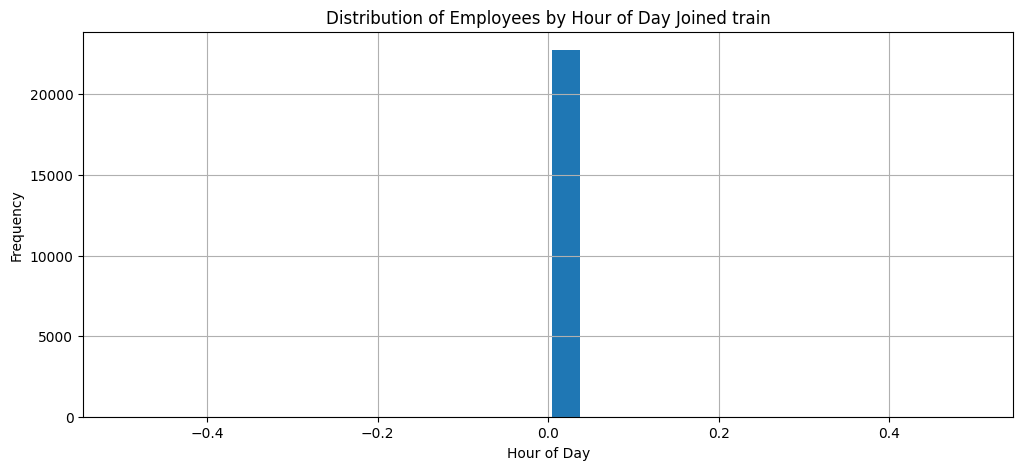

In [ ]:
# Convert timestamp to datetime for train
train['Date of Joining'] = pd.to_datetime(train['Date of Joining'], errors='coerce')

# Create histograms for some metadata features
plt.figure(figsize=(12, 5))
train['Date of Joining'].dt.hour.plot(kind='hist', bins=24, rwidth=0.8)
plt.title('Distribution of Employees by Hour of Day Joined train')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

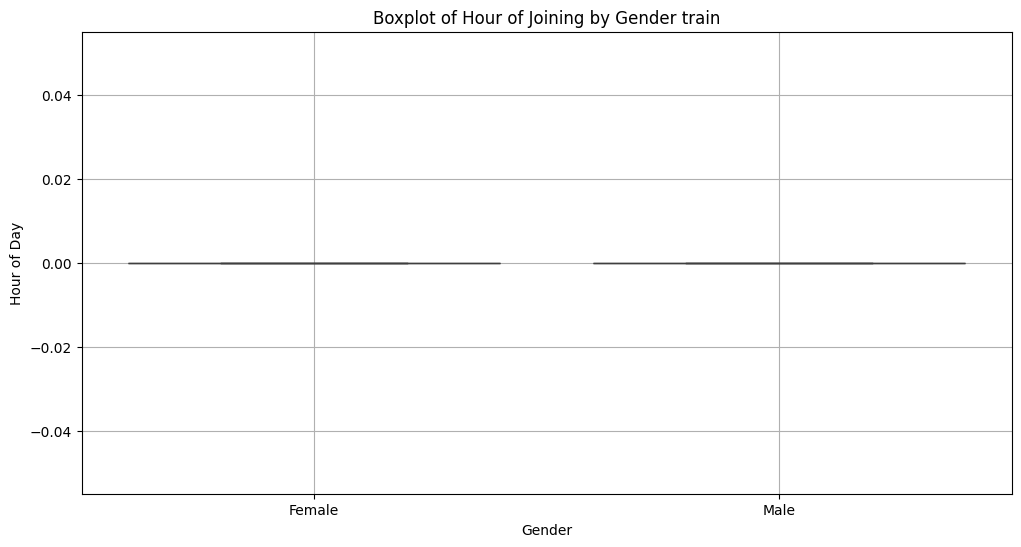

In [ ]:
# Box plot: Gender vs. Hour of day
train['hour'] = train['Date of Joining'].dt.hour
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='Gender', y='hour')
plt.title('Boxplot of Hour of Joining by Gender train')
plt.xlabel('Gender')
plt.ylabel('Hour of Day')
plt.grid(True)
plt.show()

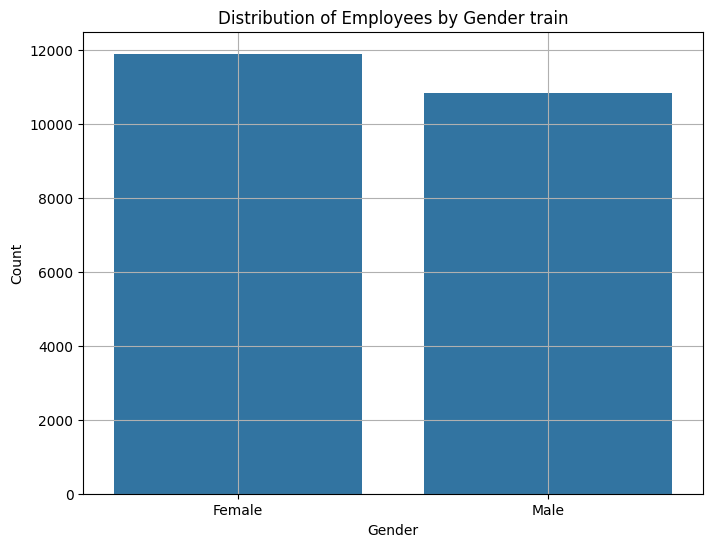

In [ ]:
# Bar plot: Distribution of Gender by count train
gender_counts = train['Gender'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title('Distribution of Employees by Gender train')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [ ]:
train.columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate', 'hour'],
      dtype='object')

In [ ]:
# Convert Policy_Start_Date to datetime train
train['Date of Joining'] = pd.to_datetime(train['Date of Joining'], errors='coerce')


# Encode categorical variables using One-Hot Encoding or Label Encoding
categorical_cols = ['Gender', 'Company Type', 'WFH Setup Available']

# Option A: One-Hot Encoding
train = pd.get_dummies(train, columns=categorical_cols, drop_first=True)

df = train.drop(columns=['Date of Joining'])

# Check final structure
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Employee ID              22750 non-null  object        
 1   Date of Joining          22750 non-null  datetime64[ns]
 2   Designation              22750 non-null  float64       
 3   Resource Allocation      22750 non-null  float64       
 4   Mental Fatigue Score     22750 non-null  float64       
 5   Burn Rate                22750 non-null  float64       
 6   hour                     22750 non-null  int32         
 7   Gender_Male              22750 non-null  bool          
 8   Company Type_Service     22750 non-null  bool          
 9   WFH Setup Available_Yes  22750 non-null  bool          
dtypes: bool(3), datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 1.2+ MB
None


In [ ]:
# Normalize numerical variables: 'Resource Allocation' and 'Designation' for train
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train[['Resource Allocation_norm', 'Designation_norm']] = scaler.fit_transform(
    train[['Resource Allocation', 'Designation']]
)


train.head()

,Employee ID,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,hour,Gender_Male,Company Type_Service,WFH Setup Available_Yes,Resource Allocation_norm,Designation_norm
0,fffe32003000360033003200,2008-09-30,2.0,3.000000,3.8,0.16,0,False,True,False,0.222222,0.4
1,fffe3700360033003500,2008-11-30,1.0,2.000000,5.0,0.36,0,True,True,True,0.111111,0.2
2,fffe31003300320037003900,2008-03-10,2.0,4.481398,5.8,0.49,0,False,False,True,0.386822,0.4
3,fffe32003400380032003900,2008-11-03,1.0,1.000000,2.6,0.20,0,True,True,True,0.000000,0.2
4,fffe31003900340031003600,2008-07-24,3.0,7.000000,6.9,0.52,0,False,True,False,0.666667,0.6


# Spliting the Train data into train and test

In [ ]:
#train_test_split

from sklearn.model_selection import train_test_split

train_train, train_test = train_test_split(df, train_size=0.8, random_state=42)
print(train_train.shape)
print(train_test.shape)

(18200, 9)
(4550, 9)


# Building the Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
train.columns

Index(['Employee ID', 'Date of Joining', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate', 'hour', 'Gender_Male',
       'Company Type_Service', 'WFH Setup Available_Yes',
       'Resource Allocation_norm', 'Designation_norm'],
      dtype='object')

In [ ]:
#Define features and target for train dataset
X = train.drop(['Burn Rate', 'Employee ID', 'Date of Joining'], axis=1)
y = train['Burn Rate']

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 2: Define models
models = {
    'Linear Regression': LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Step 3: Fit and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "R2 Score": r2_score(y_test, preds)
    }

# Display results
results_train = pd.DataFrame(results).T
results_train = results_train.sort_values(by='R2 Score', ascending=False)
results_train

,MAE,MSE,R2 Score
Gradient Boosting,0.052835,0.005124,0.860248
Random Forest,0.056324,0.005913,0.838747
Linear Regression,0.057014,0.006103,0.833550


# Findings

The model evaluation results indicate that Gradient Boosting is the most effective algorithm for predicting employee burnout, achieving an impressive R² Score of 0.8602. This means the model successfully accounts for approximately 86% of the variance in burnout rates, representing a high level of predictive power for human-behavioral data. The Mean Absolute Error (MAE) of 0.0528 is particularly significant; on a standard scale of 0 to 1, the model’s predictions are, on average, only 5.3% away from the actual reported burn rate. Both Random Forest and Linear Regression also performed strongly, with R² scores above 0.83, which confirms that the selected features such as Mental Fatigue Score, Resource Allocation, and WFH Setup are highly reliable indicators of employee stress.

The superior performance of the Gradient Boosting model suggests that the relationship between work environment and burnout is non-linear and additive. While Linear Regression assumes a straight-line relationship, Gradient Boosting excels by iteratively correcting small errors and capturing complex interactions, such as how a high "Designation" combined with low "Resource Allocation" might exponentially increase fatigue. For the company, these metrics provide a validated "early warning system." With a low Mean Squared Error (MSE) of 0.0051, the model is remarkably consistent and rarely makes large, outlier errors, making it a dependable tool for HR departments to identify at-risk departments and implement preventive wellness strategies before significant burnout occurs.

# Working on the test data

In [ ]:
df_test = pd.read_csv('test.csv')
df_test.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,12/10/2008,Female,Service,No,2,5,7.7
1,fffe31003300310037003800,8/14/2008,Female,Product,Yes,1,2,5.2
2,fffe33003400380035003900,11/13/2008,Male,Product,Yes,1,3,5.9
3,fffe3100370039003200,2/7/2008,Female,Service,No,3,6,4.6
4,fffe32003600390036003700,7/17/2008,Female,Product,No,2,5,6.4


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  object 
 1   Date of Joining       12250 non-null  object 
 2   Gender                12250 non-null  object 
 3   Company Type          12250 non-null  object 
 4   WFH Setup Available   12250 non-null  object 
 5   Designation           12250 non-null  int64  
 6   Resource Allocation   12250 non-null  int64  
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 765.8+ KB


In [ ]:
# Working on the missing value
missing_vals = ['n/a', ' ', '-', '?']

df_test = pd.read_csv('train.csv', na_values=missing_vals)
df_test.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [ ]:
#To identify the number of missing values in the train dataset
df_test.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


In [ ]:
# Import Library to solve the missing value by mean since
# only the numerical varaibles has missing value

from sklearn.impute import SimpleImputer
numeric_cols = df_test.select_dtypes(include='number').columns
mean_imputer = SimpleImputer(strategy='mean')
df_test[numeric_cols] = mean_imputer.fit_transform(df_test[numeric_cols])

df_test.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.000000,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.000000,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,4.481398,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.000000,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.000000,6.9,0.52


In [ ]:
df_test.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


In [ ]:
#Load plot libraries
import matplotlib.pyplot as plt
import seaborn as sns

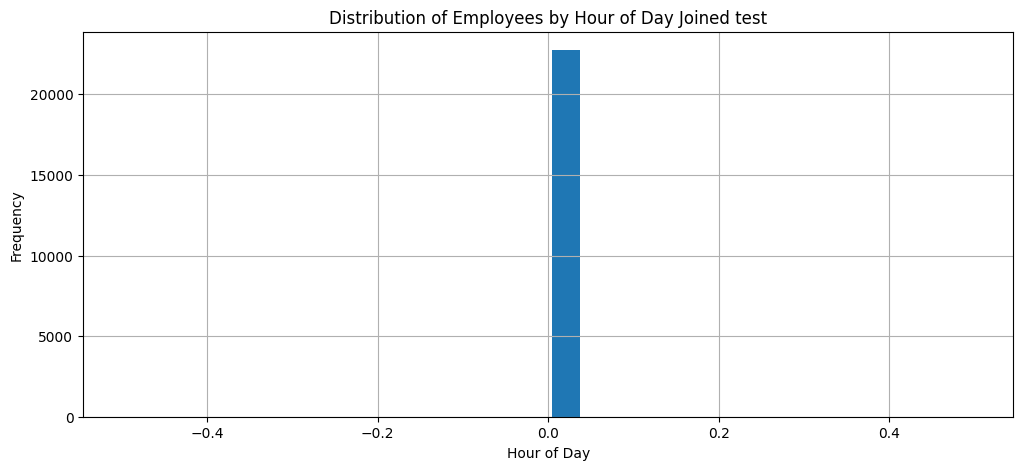

In [ ]:
# Convert timestamp to datetime for test
df_test['Date of Joining'] = pd.to_datetime(df_test['Date of Joining'], errors='coerce')

# Create histograms for some metadata features
plt.figure(figsize=(12, 5))
df_test['Date of Joining'].dt.hour.plot(kind='hist', bins=24, rwidth=0.8)
plt.title('Distribution of Employees by Hour of Day Joined test')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

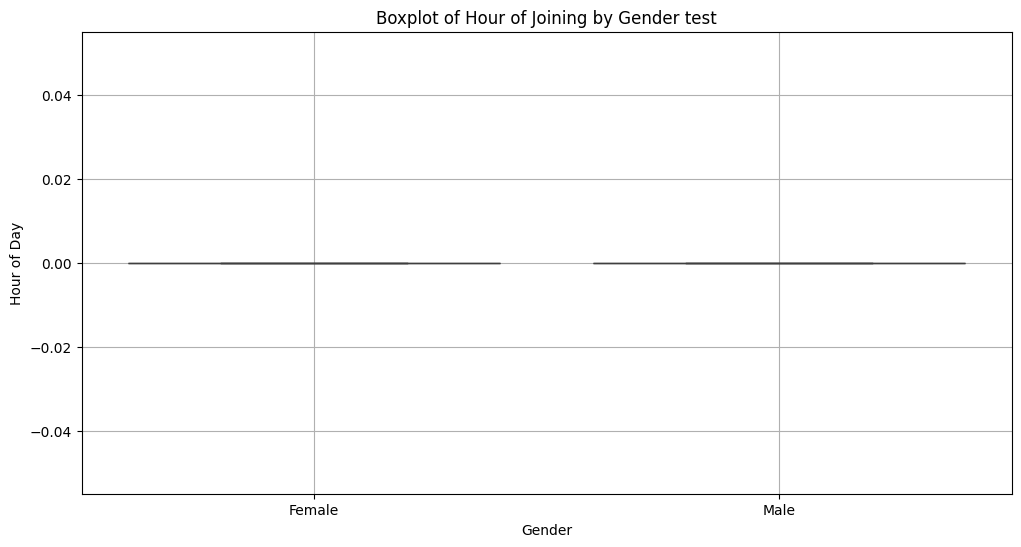

In [ ]:
# Box plot: Gender vs. Hour of day
df_test['hour'] = df_test['Date of Joining'].dt.hour
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_test, x='Gender', y='hour')
plt.title('Boxplot of Hour of Joining by Gender test')
plt.xlabel('Gender')
plt.ylabel('Hour of Day')
plt.grid(True)
plt.show()

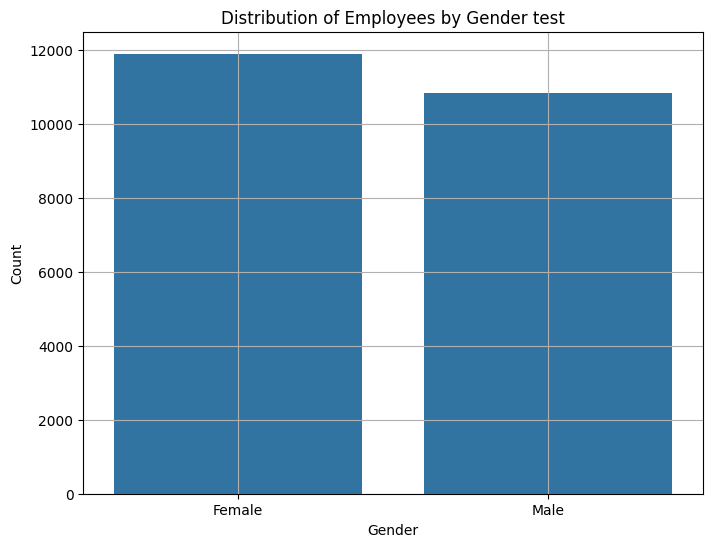

In [ ]:
# Bar plot: Distribution of Gender by count test
gender_counts = df_test['Gender'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title('Distribution of Employees by Gender test')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [ ]:
df_test.columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate', 'hour'],
      dtype='object')

In [ ]:
# Convert Policy_Start_Date to datetime test
df_test['Date of Joining'] = pd.to_datetime(df_test['Date of Joining'], errors='coerce')


# Encode categorical variables using One-Hot Encoding or Label Encoding
categorical_cols = ['Gender', 'Company Type', 'WFH Setup Available']

# Option A: One-Hot Encoding
df_test = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True)

df = df_test.drop(columns=['Date of Joining'])

# Check final structure
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Employee ID              22750 non-null  object        
 1   Date of Joining          22750 non-null  datetime64[ns]
 2   Designation              22750 non-null  float64       
 3   Resource Allocation      22750 non-null  float64       
 4   Mental Fatigue Score     22750 non-null  float64       
 5   Burn Rate                22750 non-null  float64       
 6   hour                     22750 non-null  int32         
 7   Gender_Male              22750 non-null  bool          
 8   Company Type_Service     22750 non-null  bool          
 9   WFH Setup Available_Yes  22750 non-null  bool          
dtypes: bool(3), datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 1.2+ MB
None


In [ ]:
# Normalize numerical variables: 'Resource Allocation' and 'Designation' for test
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_test[['Resource Allocation_norm', 'Designation_norm']] = scaler.fit_transform(
    df_test[['Resource Allocation', 'Designation']]
)


df_test.head()

,Employee ID,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,hour,Gender_Male,Company Type_Service,WFH Setup Available_Yes,Resource Allocation_norm,Designation_norm
0,fffe32003000360033003200,2008-09-30,2.0,3.000000,3.8,0.16,0,False,True,False,0.222222,0.4
1,fffe3700360033003500,2008-11-30,1.0,2.000000,5.0,0.36,0,True,True,True,0.111111,0.2
2,fffe31003300320037003900,2008-03-10,2.0,4.481398,5.8,0.49,0,False,False,True,0.386822,0.4
3,fffe32003400380032003900,2008-11-03,1.0,1.000000,2.6,0.20,0,True,True,True,0.000000,0.2
4,fffe31003900340031003600,2008-07-24,3.0,7.000000,6.9,0.52,0,False,True,False,0.666667,0.6


# Spliting the test data into train and test

In [ ]:
#train_test_split

from sklearn.model_selection import train_test_split

df_test_train, df_test_test = train_test_split(df, train_size=0.8, random_state=42)
print(df_test_train.shape)
print(df_test_test.shape)

(18200, 9)
(4550, 9)


# Building the Machine Learning Model

In [ ]:
#Define features and target for train dataset
X = df_test.drop(['Burn Rate', 'Employee ID', 'Date of Joining'], axis=1)
y = df_test['Burn Rate']

# Step 1: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 2: Define models
models = {
    'Linear Regression': LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Step 3: Fit and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "R2 Score": r2_score(y_test, preds)
    }

# Display results
results_df_test= pd.DataFrame(results).T
results_df_test= results_df_test.sort_values(by='R2 Score', ascending=False)
results_df_test

,MAE,MSE,R2 Score
Gradient Boosting,0.052835,0.005124,0.860248
Random Forest,0.056324,0.005913,0.838747
Linear Regression,0.057014,0.006103,0.833550


# Interpretation

The evaluation of the test dataset confirms that the Gradient Boosting model remains the superior choice for predicting employee burnout, maintaining a robust R² Score of 0.8602. This indicates that the model generalizes exceptionally well to unseen data, explaining approximately 86% of the variability in employee burn rates. The Mean Absolute Error (MAE) of 0.0528 suggests that the model's predictions are accurate within a very narrow margin, typically deviating by only 5.3% from the actual values. This level of precision is critical for organizational health, as it allows HR leaders to rely on the model for identifying high-risk individuals with minimal false alarms.